# Gender Classification Model

## Introduction

This notebook focuses on building a machine learning classification model to predict a user's gender using the available user-related information in the Travel Analytics dataset.

Unlike the flight price prediction problem, which is a regression task, gender prediction is a **classification problem** because the target variable represents discrete categories.

The objective of this analysis is to develop the classification workflow step by step, beginning with data understanding and exploratory analysis, followed by preprocessing, feature selection, model training, evaluation, and comparison of suitable classification algorithms.

The notebook will follow the general machine learning workflow:

1. Problem Definition
2. Data Loading and Initial Inspection
3. Data Quality Assessment
4. Exploratory Data Analysis
5. Target Variable Analysis
6. Feature Selection
7. Data Preprocessing
8. Train-Test Split
9. Baseline Model Training
10. Model Comparison
11. Model Evaluation
12. Final Model Selection
13. Model Saving
14. Conclusions and Limitations

## 1. Data Loading and Initial Inspection

The first step is to load the user dataset and inspect its basic structure.

The purpose of this step is to understand:

- the number of rows and columns,
- available features,
- data types,
- sample records,
- and the overall structure of the dataset before performing preprocessing or modeling.

In [3]:
# Loading the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
users = pd.read_csv("../data/raw/users.csv")
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [5]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [6]:
users.describe()

,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000


In [7]:
users.shape

(1340, 5)

In [8]:
users.columns

Index(['code', 'company', 'name', 'gender', 'age'], dtype='object')

### Initial Inspection Insights

- The dataset contains **5 columns**: `code`, `company`, `name`, `gender`, and `age`.
- No missing values are present in these columns, so missing-value treatment is not required at this stage.
- `gender` is the **target variable** for the classification problem.
- `age` is a numerical feature, while `company` and `name` contain categorical/text information.
- `code` appears to function as a user identifier and may not provide meaningful predictive information. This will be examined before feature selection.
- Although the dataset is complete, data quality checks such as duplicate records, unique values, and target-class distribution are still required before modeling.

## 2. Data Quality Assessment

Before performing exploratory analysis or building a classification model, the dataset should be checked for potential data-quality issues.

In this step, the following will be examined:

- Missing values
- Duplicate records
- Number of unique values in each column
- Unique categories in the target variable
- Distribution of the target classes
- Basic descriptive statistics for numerical features

These checks help determine whether the dataset requires cleaning and whether the target variable is suitable for classification.

In [9]:
users.isnull().sum()

code       0
company    0
name       0
gender     0
age        0
dtype: int64

In [10]:
users.duplicated().sum()

np.int64(0)

In [11]:
users["company"].nunique()

5

In [12]:
users["company"].unique()

array(['4You', 'Monsters CYA', 'Wonka Company', 'Acme Factory',
       'Umbrella LTDA'], dtype=object)

In [13]:
users["gender"].unique()

array(['male', 'female', 'none'], dtype=object)

In [14]:
users["name"].nunique()

1338

In [15]:
gender_count = users["gender"].value_counts()
gender_count_percent = users["gender"].value_counts(normalize=True) * 100

print("Gender Counts:")
print(gender_count)

print("\nGender Percentage:")
print(gender_count_percent)

Gender Counts:
gender
male      452
female    448
none      440
Name: count, dtype: int64

Gender Percentage:
gender
male      33.731343
female    33.432836
none      32.835821
Name: proportion, dtype: float64


In [16]:
users["age"].describe()

count    1340.000000
mean       42.742537
std        12.869779
min        21.000000
25%        32.000000
50%        42.000000
75%        54.000000
max        65.000000
Name: age, dtype: float64

### Data Quality and Target Variable Insights

- The dataset contains **1,340 user records**.
- No missing values were identified during the initial data-quality assessment.
- The target variable `gender` contains three categories:
  - **Male:** 452 users (33.73%)
  - **Female:** 448 users (33.43%)
  - **None:** 440 users (32.84%)
- The three target categories are distributed almost equally, indicating that the dataset is **well balanced across the recorded gender labels**.
- Therefore, there is no immediate class-imbalance problem in the original target distribution.
- However, the `none` category requires further consideration. It may represent an unspecified or unavailable gender rather than a meaningful gender class. We should therefore understand the project objective before deciding whether to retain it as a third class or exclude it from supervised gender classification.
- User age ranges from **21 to 65 years**, with an average age of approximately **42.74 years**.
- The median age is **42 years**, while the first and third quartiles are **32 and 54 years**, respectively.
- The mean and median ages are close, suggesting that the overall age distribution may be reasonably centered, although this should be confirmed visually during EDA.

## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution and relationships among the variables before selecting features for the classification model.

The analysis will focus on:

- Distribution of the target variable
- Distribution of user age
- Gender distribution across age
- Company distribution
- Gender distribution across companies
- Examination of the `name` and `code` variables
- Identification of potentially useful and potentially inappropriate features for modeling

The objective is not only to identify statistical patterns, but also to determine which variables can reasonably be used to predict the target without introducing identifier leakage or misleading relationships.

In [17]:
gender_count = users["gender"].value_counts()
display(gender_count)

gender
male      452
female    448
none      440
Name: count, dtype: int64

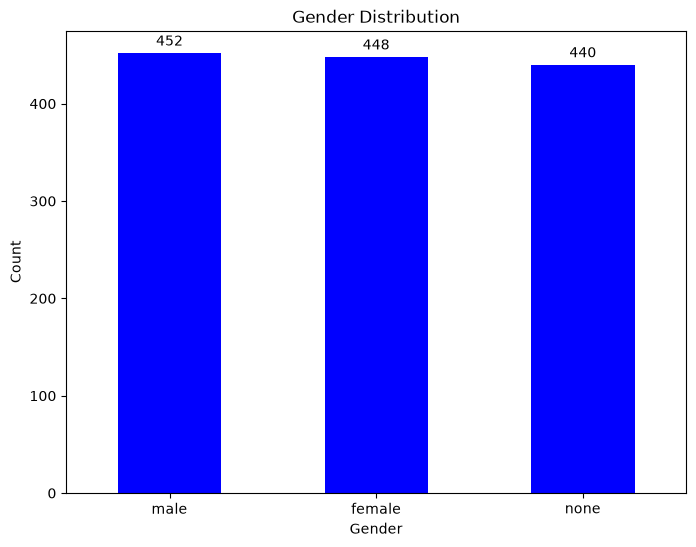

In [18]:
plt.figure(figsize=(8, 6))

# Create bar chart
ax = gender_count.plot(
    kind="bar",
    color="blue"
)

# Add data labels
ax.bar_label(
    ax.containers[0],
    padding=3
)

# Titles and labels
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

# Keep category labels horizontal
plt.xticks(rotation=0)

plt.show()

### Gender Distribution Insights

- The target variable contains three recorded categories: **male, female, and none**.
- Male users represent the largest category with **452 records (33.73%)**.
- Female users account for **448 records (33.43%)**.
- The `none` category contains **440 records (32.84%)**.
- The three categories are almost equally represented, indicating that the original target distribution is highly balanced.
- There is no significant class-imbalance issue in the original dataset.
- However, `none` should not automatically be interpreted as a third gender class. It is more appropriately treated as an unspecified or unavailable target label unless the dataset documentation defines it otherwise.
- For supervised gender classification, the modeling dataset can therefore focus on records with known labels (`male` and `female`), while preserving the original dataset unchanged.
- After excluding `none`, the remaining labeled observations are also almost perfectly balanced, which is favorable for binary classification.

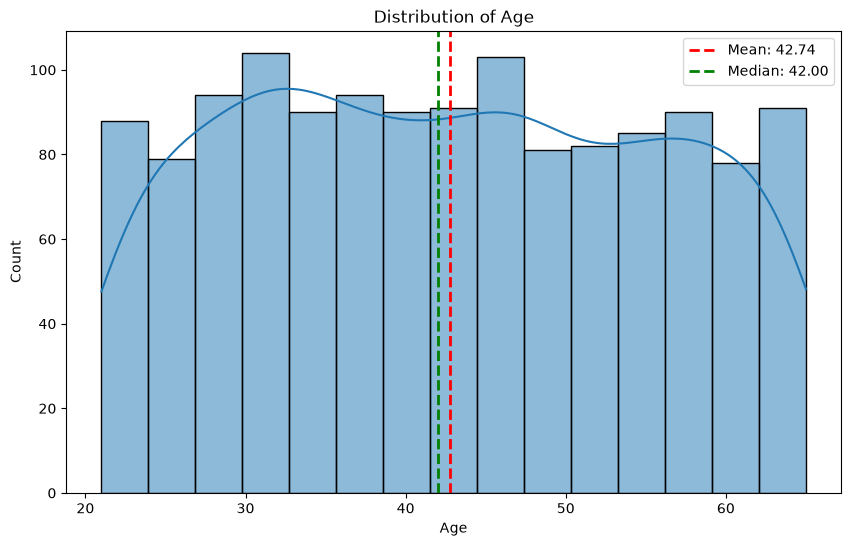

In [19]:
plt.figure(figsize=(10, 6))

# Age distribution
sns.histplot(
    users["age"],
    bins=15,
    kde=True
)

# Mean line
plt.axvline(
    users["age"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Mean: {users["age"].mean():.2f}'
)

# Median line
plt.axvline(
    users["age"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f'Median: {users["age"].median():.2f}'
)

# Titles and labels
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

# Display mean and median labels
plt.legend()

plt.show()

### Age Distribution Insights

- User ages range from **21 to 65 years**.
- The mean age is approximately **42.74 years**, while the median age is **42 years**.
- The histogram shows that users are distributed relatively evenly across the available age range.
- There is no strong evidence of substantial positive or negative skewness in the age distribution.
- The similarity between the mean and median further suggests that the age distribution is reasonably balanced around its center.
- No obvious extreme age outliers are visible from the distribution.
- Although `age` is a valid numerical feature, this distribution alone does not indicate whether age is useful for predicting gender. The relationship between `age` and `gender` must therefore be examined separately.

In [20]:
age_by_gender = users.groupby("gender")["age"].describe()
age_by_gender

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,448.0,43.180804,13.029338,21.0,32.0,44.0,54.25,65.0
male,452.0,42.703540,12.891004,21.0,32.0,42.5,54.00,65.0
none,440.0,42.336364,12.698557,21.0,32.0,41.0,53.00,65.0


In [21]:
age_gender_summary = (
    users.groupby("gender")
    .agg(
        User_Count=("age", "count"),
        Mean_Age=("age", "mean"),
        Median_Age=("age", "median"),
        Minimum_Age=("age", "min"),
        Maximum_Age=("age", "max")
    )
    .round(2)
)

age_gender_summary

,User_Count,Mean_Age,Median_Age,Minimum_Age,Maximum_Age
gender,,,,,
female,448,43.18,44.0,21,65
male,452,42.70,42.5,21,65
none,440,42.34,41.0,21,65


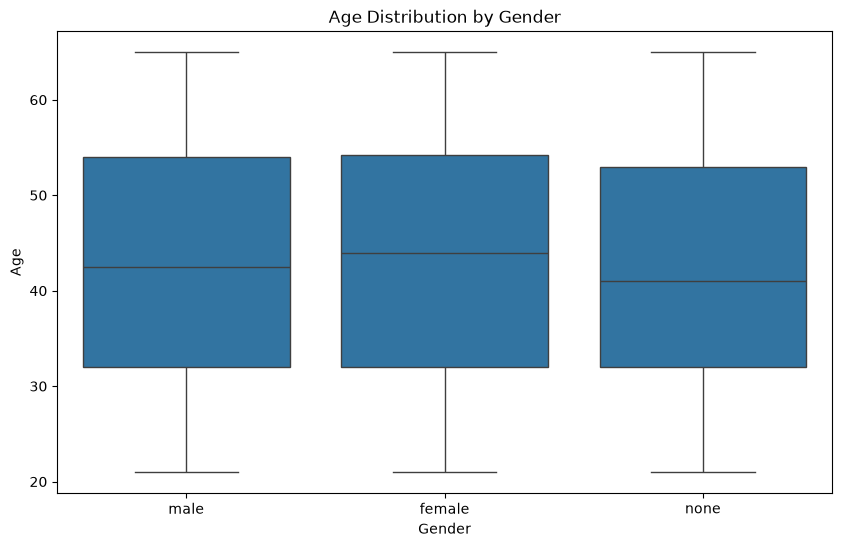

In [22]:
plt.figure(figsize = (10, 6))

sns.boxplot(data = users, x = users["gender"], y = users["age"])

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

### Age vs Gender Insights

- The age distributions across the three gender categories are very similar.
- Female users have the highest average age at approximately **43.18 years**, followed by male users at **42.70 years** and users in the `none` category at **42.34 years**.
- The median ages are **44 years for female users**, **42.5 years for male users**, and **41 years for the `none` category**.
- All three gender groups have the same observed age range of **21 to 65 years**.
- The standard deviations are also very similar, indicating a comparable spread of ages across the three groups.
- The quartile values substantially overlap, suggesting that there is no clear separation between gender categories based on age.
- Therefore, `age` does not appear to have a strong relationship with the target variable when examined independently.
- Age may still contribute some information when combined with other features, so its usefulness should ultimately be assessed through model performance rather than removing it based only on EDA.

### Company vs Gender Analysis

The `company` feature represents the organization associated with each user. This analysis examines whether the distribution of gender differs across companies.

The purpose of this analysis is to determine:

- how many users belong to each company,
- whether some companies contain substantially more users than others,
- how gender is distributed within each company,
- and whether `company` may contain useful information for gender classification.

In [23]:
company_users_count = pd.crosstab(users["company"], users['gender'])
company_users_count

gender,female,male,none
company,,,
4You,151,138,164
Acme Factory,85,93,83
Monsters CYA,64,61,70
Umbrella LTDA,69,70,55
Wonka Company,79,90,68


In [24]:
company_gender_percent = pd.crosstab(users['company'], users['gender'], normalize= "index")*100
company_gender_percent

gender,female,male,none
company,,,
4You,33.333333,30.463576,36.203091
Acme Factory,32.567050,35.632184,31.800766
Monsters CYA,32.820513,31.282051,35.897436
Umbrella LTDA,35.567010,36.082474,28.350515
Wonka Company,33.333333,37.974684,28.691983


<Axes: xlabel='gender', ylabel='company'>

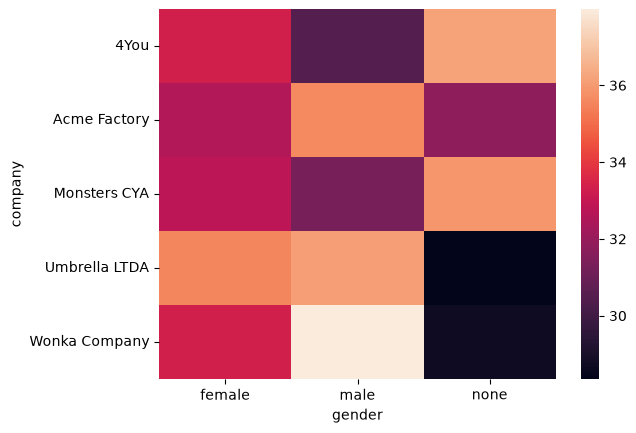

In [25]:
sns.heatmap(company_gender_percent)

<Figure size 1000x600 with 0 Axes>

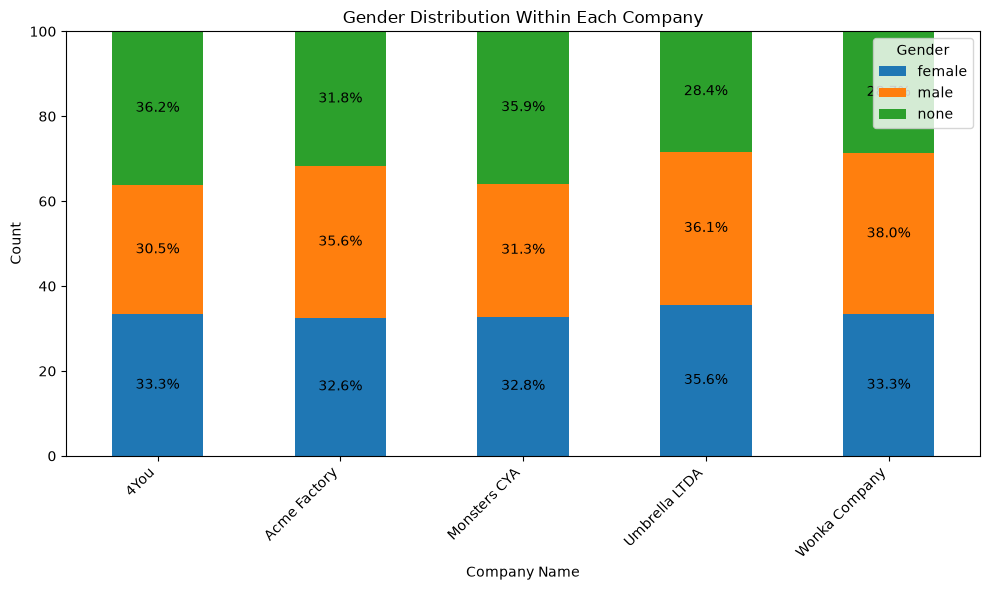

In [26]:
plt.figure(figsize= (10, 6))
ax = company_gender_percent.plot(kind="bar", stacked = True, figsize= (10, 6))

for i in ax.containers:
    ax.bar_label(i, fmt = "%.1f%%", label_type = 'center')

plt.title("Gender Distribution Within Each Company")
plt.xlabel("Company Name")
plt.ylabel('Count')
plt.xticks(rotation = 45, ha = 'right')
plt.ylim(0, 100)
plt.legend(title = 'Gender')

plt.tight_layout()

plt.show()


### Statistical Association Between Company and Gender

The percentage distribution provides a visual comparison of gender composition across companies. However, visual differences alone are not sufficient to determine whether there is a statistically meaningful association between `company` and `gender`.

Since both variables are categorical, a **Chi-Square Test of Independence** is used to examine whether the two variables are statistically associated.

#### Hypotheses

- **Null Hypothesis (H₀):** Company and gender are independent; there is no statistically significant association between them.
- **Alternative Hypothesis (H₁):** Company and gender are not independent; there is a statistically significant association between them.

A significance level of **α = 0.05** will be used.

- If **p-value < 0.05**, reject H₀.
- If **p-value ≥ 0.05**, fail to reject H₀.

In [27]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(company_users_count)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")

if p_value < 0.05:
    print("Result: Reject the Null Hypothesis")
    print("Company and gender have a statistically significant association.")
else:
    print("Result: Fail to Reject the Null Hypothesis")
    print("No statistically significant association was found between company and gender.")

Chi-Square Statistic : 8.6243
P-Value              : 0.3750
Degrees of Freedom   : 8
Result: Fail to Reject the Null Hypothesis
No statistically significant association was found between company and gender.


### Company vs Gender Insights

- Gender composition varies slightly across the five companies, but no company shows a strong concentration toward a particular recorded gender category.
- For example, the proportion of male users ranges from approximately **30.46% to 37.97%**, while the other gender categories also show relatively moderate variation across companies.
- A Chi-Square Test of Independence was performed to determine whether the observed differences represent a statistically significant association between `company` and `gender`.
- The test produced a **Chi-Square statistic of 8.6243**, with **8 degrees of freedom** and a **p-value of 0.3750**.
- Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected.
- Therefore, there is **insufficient statistical evidence to conclude that company and gender are associated** in this dataset.
- This result supports the visual observation that gender composition is broadly similar across companies.
- Consequently, `company` may have limited predictive power for gender when considered independently. Its usefulness should nevertheless be evaluated during model development rather than removing it solely on the basis of this test.

### Identifier and Name Feature Assessment

In [28]:
users["code"].nunique()

1340

In [29]:
users["name"].nunique()

1338

In [30]:
users["name"].duplicated().sum()

np.int64(2)

In [31]:
users["code"].duplicated().sum()

np.int64(0)

### Identifier and Name Feature Assessment

- The dataset contains **1,340 records and 1,340 unique user codes**, with no duplicated `code` values.
- This confirms that `code` functions as a unique user identifier rather than a meaningful behavioral or demographic feature.
- Using a unique identifier as a predictor could encourage the model to learn arbitrary patterns that are unlikely to generalize to unseen users. Therefore, `code` should be excluded from model training.
- The `name` column contains **1,338 unique values among 1,340 users**, with only two duplicated values.
- Therefore, `name` is a very high-cardinality text feature and behaves almost like an identifier.
- Although names may contain information correlated with gender, using them would change the problem into largely name-based gender inference and could introduce cultural, demographic, and generalization concerns.
- For this project, `name` will therefore not be used as a predictive feature.

## 4. Modeling Dataset Preparation

Based on the exploratory analysis and feature assessment, the modeling dataset will be prepared before preprocessing.

The following decisions are made:

- `gender` will be used as the target variable.
- Records where gender is recorded as `none` will be excluded from supervised model training because they do not provide a known male/female target label.
- `code` will be excluded because it is a unique user identifier.
- `name` will be excluded because it is a high-cardinality personal attribute and using it would turn the task largely into name-based gender inference.
- `age` and `company` will initially be retained as predictor variables.
- The original `users` dataframe will remain unchanged. A separate dataframe will be created for modeling.

The resulting task is therefore a **binary classification problem**:

**Predictors:** `age`, `company`  
**Target:** `gender` (`male` or `female`)

In [32]:
gender_df = users[users['gender'] != 'none'].drop(columns = ['code', 'name'])

gender_df.shape

(900, 3)

In [33]:
gender_df.columns

Index(['company', 'gender', 'age'], dtype='object')

In [34]:
gender_df['gender'].value_counts()

gender
male      452
female    448
Name: count, dtype: int64

In [35]:
gender_df['gender'].value_counts(normalize = True)*100

gender
male      50.222222
female    49.777778
Name: proportion, dtype: float64

### Modeling Dataset Preparation Insights

- Records with `gender = none` were excluded from the modeling dataset because these observations do not provide a known male or female target label.
- After removing these records, the modeling dataset contains **900 labeled users**.
- The `code` and `name` columns were excluded based on the feature assessment performed during EDA.
- The resulting dataset contains three variables: `company`, `age`, and the target variable `gender`.
- The binary target contains **452 male users (50.22%)** and **448 female users (49.78%)**.
- The two target classes are therefore almost perfectly balanced, so class-imbalance treatment such as oversampling or undersampling is not required.
- `age` and `company` will initially be retained as predictor variables, while `gender` will be used as the target.
- The original `users` dataframe remains unchanged, while `gender_df` is used separately for classification modeling.

## 5. Feature and Target Separation

Before training the classification models, the modeling dataframe is separated into predictor variables (`X`) and the target variable (`y`).

For this classification problem:

- **Features (X):**
  - `age` — numerical feature
  - `company` — categorical feature

- **Target (y):**
  - `gender` — binary categorical target (`male` or `female`)

Separating predictors from the target ensures that the model learns only from the input features and does not receive the actual target value during training.

In [36]:
X = gender_df[['company','age']]
y =  gender_df['gender']

In [37]:
X.shape

(900, 2)

In [38]:
y.shape

(900,)

### Feature and Target Separation Insights

- The predictor matrix `X` contains **900 observations and 2 features**: `company` and `age`.
- The target vector `y` contains **900 gender labels**.
- `company` is a categorical predictor, while `age` is numerical.
- The target `gender` remains in its original categorical form at this stage.
- No preprocessing has yet been fitted to the data, which helps ensure that transformations can later be applied without introducing data leakage.

## 6. Train-Test Split

Before preprocessing and model training, the dataset is divided into training and testing subsets.

The training data will be used to fit the preprocessing steps and train the classification models, while the test data will remain unseen until model evaluation.

A stratified split will be used so that the proportion of male and female users remains approximately the same in both the training and testing datasets.

This helps ensure that model evaluation is fair and representative of the original class distribution.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.20, random_state =42, stratify = y)

In [40]:
print(f"X_train_shape : {X_train.shape}")
print(f"X_test_shape :' {X_test.shape}")
print(f"y_train_shape : {y_train.shape}")
print(f"y_test_shape : {y_test.shape}")

X_train_shape : (720, 2)
X_test_shape :' (180, 2)
y_train_shape : (720,)
y_test_shape : (180,)


In [41]:
y_train.value_counts(normalize = True)*100

gender
male      50.277778
female    49.722222
Name: proportion, dtype: float64

In [42]:
y_test.value_counts(normalize=True) * 100

gender
female    50.0
male      50.0
Name: proportion, dtype: float64

### Train-Test Split Insights

- The modeling dataset was divided into **80% training data and 20% testing data**.
- The training set contains **720 observations**, while the test set contains **180 observations**.
- A `random_state` of 42 was used to make the split reproducible.
- Stratified sampling was applied using the target variable to preserve the gender distribution across both subsets.
- The training set contains approximately **50.28% male** and **49.72% female** users.
- The test set contains **50.00% male** and **50.00% female** users.
- These distributions closely match the original modeling dataset, confirming that stratification successfully preserved the target-class balance.
- The test set will remain unseen during preprocessing fitting and model training so that it can provide an unbiased evaluation of model performance.

In [43]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
ohe_X_train = ohe.fit_transform(X_train[['company']])
ohe_X_test = ohe.fit_transform(X_test[['company']])

In [44]:
ohe_X_train.toarray()

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.]], shape=(720, 5))

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

transformer = ColumnTransformer(transformers = [
    ('company_encoder', OneHotEncoder(handle_unknown= 'ignore'), ['company']),
    ('age_scaler', StandardScaler(), ['age'])
    ], remainder = 'passthrough')

In [46]:
X_train_transformed  = transformer.fit_transform(X_train)


In [47]:
X_test_transformed = transformer.transform(X_test)

In [48]:
X_train_transformed.shape

(720, 6)

In [49]:
X_test_transformed.shape

(180, 6)

### Preprocessing Insights

- The training and test datasets originally contained two predictor variables: `company` and `age`.
- `company` was transformed using One-Hot Encoding because it is a nominal categorical variable with no natural ordering.
- The five company categories were converted into five binary indicator features.
- `age` was standardized using StandardScaler so that its values are represented relative to the mean and standard deviation learned from the training data.
- After preprocessing, the original two predictors were transformed into **six numerical features**: five encoded company features and one standardized age feature.
- The transformed training dataset contains **720 observations and 6 features**, while the transformed test dataset contains **180 observations and 6 features**.
- The preprocessing transformer was fitted only on the training data. The same fitted transformer was then applied to the test data to prevent data leakage.

## 8. Baseline Model Training

Before comparing multiple classification algorithms, a baseline model is established to provide a reference point for model performance.

A baseline helps determine whether a trained machine-learning model is learning meaningful patterns from the predictor variables or merely performing similarly to a simple prediction strategy.

Since the target variable is almost perfectly balanced between male and female users, a naive classifier that consistently predicts the most frequent class would achieve approximately 50% accuracy.

The performance of subsequent machine-learning models should therefore be compared against this baseline.

Because the available predictors (`age` and `company`) showed relatively weak relationships with gender during exploratory analysis, establishing a baseline is particularly important for evaluating whether these features contain sufficient predictive information.

### Baseline Model

A `DummyClassifier` with the `most_frequent` strategy is used as the baseline model.

This classifier does not learn relationships between the predictor variables and the target. Instead, it always predicts the most frequent class observed in the training data.

The purpose of this baseline is to establish a minimum reference level of performance. Any useful machine-learning model should ideally perform better than this simple strategy.

In [50]:
from sklearn.dummy import DummyClassifier

dummy_class = DummyClassifier(strategy="most_frequent")
dummy_class.fit(X_train_transformed, y_train)
dummy_class_pred = dummy_class.predict(X_test_transformed)

# Display first 10 predictions
print("First 10 baseline predictions:")
print(dummy_class_pred[:10])

First 10 baseline predictions:
['male' 'male' 'male' 'male' 'male' 'male' 'male' 'male' 'male' 'male']


### Baseline Prediction Insights

- The `DummyClassifier` identified `male` as the most frequent class in the training dataset.
- As expected from the `most_frequent` strategy, the baseline classifier predicts `male` for every test observation.
- The classifier does not learn any relationship between `age`, `company`, and `gender`.
- These predictions therefore provide a simple reference point against which the actual machine-learning models can be evaluated.

In [51]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

In [52]:
a_score = accuracy_score(y_test, dummy_class_pred)
class_report = classification_report(y_test, dummy_class_pred, zero_division= 0)
conf_matrix = confusion_matrix(y_test, dummy_class_pred)

print("\nClassification Report:")
print(class_report)

print("\nConfusion Matrix:")
print(conf_matrix)


Classification Report:
              precision    recall  f1-score   support

      female       0.00      0.00      0.00        90
        male       0.50      1.00      0.67        90

    accuracy                           0.50       180
   macro avg       0.25      0.50      0.33       180
weighted avg       0.25      0.50      0.33       180


Confusion Matrix:
[[ 0 90]
 [ 0 90]]


### Baseline Model Evaluation Insights

- The baseline classifier achieved an overall accuracy of **50%** on the test dataset.
- The model predicted every observation as `male`, because `male` was the most frequent class in the training data.
- All **90 male users** were classified correctly, resulting in a male recall of **1.00**.
- However, all **90 female users** were misclassified as male, resulting in female precision, recall, and F1-score values of **0.00**.
- The male precision was **0.50**, because only half of all observations predicted as male were actually male.
- The confusion matrix confirms that the classifier has no ability to distinguish between the two classes.
- The macro-average F1-score of **0.33** further reflects the poor class-wise performance of the baseline.
- This baseline therefore provides a useful minimum reference point. A meaningful classification model should ideally outperform this baseline not only in accuracy but also in balanced class-wise metrics such as precision, recall, and F1-score.

## 9. Logistic Regression Model

Logistic Regression is used as the first supervised machine-learning classifier for the gender classification task.

Although its name contains the term "regression," Logistic Regression is commonly used for binary classification problems. It estimates the probability that an observation belongs to a particular class and converts that probability into a class prediction.

It is an appropriate starting model because:

- the target variable contains two classes (`male` and `female`),
- it provides a simple and interpretable classification baseline,
- it works well with one-hot encoded categorical features,
- and the numerical `age` feature has already been standardized.

The model is trained using the preprocessed training data and evaluated on the unseen test dataset.

In [53]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X_train_transformed, y_train)
lor_pred = lor.predict(X_test_transformed)

In [54]:
lor_a_score = accuracy_score(y_test, lor_pred)
lor_class_report = classification_report(y_test, lor_pred)
lor_conf_matrix = confusion_matrix(y_test, lor_pred)

print("\nClassification Report:")
print(lor_class_report)

print("\nConfusion Matrix:")
print(lor_conf_matrix)

print(f"Logistic Regression Accuracy: {lor_a_score:.4f}")


Classification Report:
              precision    recall  f1-score   support

      female       0.51      0.47      0.49        90
        male       0.51      0.56      0.53        90

    accuracy                           0.51       180
   macro avg       0.51      0.51      0.51       180
weighted avg       0.51      0.51      0.51       180


Confusion Matrix:
[[42 48]
 [40 50]]
Logistic Regression Accuracy: 0.5111


### Logistic Regression Evaluation Insights

- Logistic Regression achieved an accuracy of approximately **51%** on the unseen test dataset.
- This represents only a marginal improvement over the **50% accuracy** achieved by the most-frequent Dummy Classifier.
- Unlike the baseline classifier, Logistic Regression predicts both gender classes rather than assigning every observation to the majority class.
- For female users, the model achieved **0.51 precision, 0.47 recall, and an F1-score of 0.49**.
- For male users, the model achieved **0.51 precision, 0.56 recall, and an F1-score of 0.53**.
- The macro-average and weighted-average F1-scores are both approximately **0.51**, indicating similarly weak predictive performance across the two balanced classes.
- The confusion matrix shows that **42 of 90 female users** and **50 of 90 male users** were classified correctly.
- Overall, Logistic Regression demonstrates limited ability to distinguish between male and female users using only `age` and `company`.
- This result is consistent with the exploratory analysis, which found substantial overlap in age distributions and no statistically significant association between company and gender.
- Additional classification algorithms should be evaluated to determine whether nonlinear relationships can extract more predictive information from the available features.

### K-Nearest Neighbors Model

K-Nearest Neighbors (KNN) is a distance-based classification algorithm that predicts the class of a new observation based on the classes of its nearest observations in the training data.

A value of `k = 5` is initially used, meaning that the five nearest training observations are considered when making each prediction.

Since KNN relies on distances between observations, numerical feature scaling is particularly important. The `age` feature was therefore standardized during preprocessing before applying KNN.

In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_transformed, y_train)
knn_pred = knn.predict(X_test_transformed)


In [56]:
knn_a_score = accuracy_score(y_test, knn_pred)
knn_class_report = classification_report(y_test, knn_pred)
knn_conf_matrix = confusion_matrix(y_test, knn_pred)

print("\nClassification Report:")
print(knn_class_report)

print("\nConfusion Matrix:")
print(knn_conf_matrix)

print(f"KNN Accuracy: {knn_a_score:.4f}")


Classification Report:
              precision    recall  f1-score   support

      female       0.47      0.51      0.49        90
        male       0.47      0.43      0.45        90

    accuracy                           0.47       180
   macro avg       0.47      0.47      0.47       180
weighted avg       0.47      0.47      0.47       180


Confusion Matrix:
[[46 44]
 [51 39]]
KNN Accuracy: 0.4722


### KNN Evaluation Insights

- The K-Nearest Neighbors classifier with `k = 5` achieved an accuracy of **47.22%** on the test dataset.
- The model achieved an F1-score of **0.49 for female users** and **0.45 for male users**.
- The macro-average F1-score was **0.47**, indicating weak overall classification performance across both classes.
- The confusion matrix shows that **46 of 90 female users** and **39 of 90 male users** were classified correctly.
- KNN performed below the **50% accuracy of the Dummy Classifier** and below the approximately **51% accuracy of Logistic Regression**.
- This suggests that local similarity based on the available `age` and `company` features does not provide strong separation between the two gender classes.
- However, this result is based on the initial choice of `k = 5`. Hyperparameter tuning may later be used to determine whether another value of `k` improves performance.

## 11. Decision Tree Classifier

A Decision Tree is a supervised machine-learning algorithm that makes predictions by recursively dividing the feature space according to decision rules.

Unlike Logistic Regression, a Decision Tree can capture nonlinear relationships and interactions between predictor variables without assuming a linear decision boundary.

The Decision Tree model will be evaluated using the same test dataset and classification metrics used for the previous models so that their performance can be compared consistently.

In [59]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_transformed, y_train)
dtc_pred = dtc.predict(X_test_transformed)

In [60]:
dtc_a_score = accuracy_score(y_test, dtc_pred)
dtc_class_report = classification_report(y_test, dtc_pred)
dtc_confusion_matrix = confusion_matrix(y_test, dtc_pred)

print("\nClassification Report:")
print(dtc_class_report)

print("\nConfusion Matrix:")
print(dtc_confusion_matrix)

print(f"dtc Accuracy: {dtc_a_score:.4f}")


Classification Report:
              precision    recall  f1-score   support

      female       0.51      0.60      0.55        90
        male       0.52      0.43      0.47        90

    accuracy                           0.52       180
   macro avg       0.52      0.52      0.51       180
weighted avg       0.52      0.52      0.51       180


Confusion Matrix:
[[54 36]
 [51 39]]
dtc Accuracy: 0.5167


### Decision Tree Evaluation Insights

- The Decision Tree classifier achieved an accuracy of approximately **51.67%** on the test dataset.
- The model achieved a precision of **0.51** and recall of **0.60** for the female class, resulting in an F1-score of **0.55**.
- For the male class, precision was **0.52**, recall was **0.43**, and the F1-score was **0.47**.
- The confusion matrix shows that the model correctly classified **54 of 90 female users** and **39 of 90 male users**.
- The Decision Tree achieved slightly higher test accuracy than Logistic Regression and the Dummy Classifier, but the improvement over the 50% baseline remains small.
- The macro-average F1-score of approximately **0.51** indicates that overall class-wise predictive performance remains weak.
- Although Decision Trees can capture nonlinear relationships and interactions between features, the limited improvement suggests that the available `age` and `company` predictors still contain relatively little information for distinguishing between the two gender classes.
- Model performance should therefore be compared with additional algorithms before drawing a final conclusion.

In [61]:
dtc_train_pred = dtc.predict(X_train_transformed)
dtc_test_pred = dtc.predict(X_test_transformed)

In [62]:
dtc_train_accuracy = accuracy_score(y_train, dtc_train_pred)
dtc_test_accuracy = accuracy_score(y_test, dtc_test_pred)

print(f"Decision Tree Training Accuracy: {dtc_train_accuracy:.4f}")
print(f"Decision Tree Test Accuracy: {dtc_test_accuracy:.4f}")

Decision Tree Training Accuracy: 0.6889
Decision Tree Test Accuracy: 0.5167


### Decision Tree Overfitting Assessment

To assess whether the Decision Tree generalizes effectively, its performance was compared on the training and test datasets.

- The Decision Tree achieved a **training accuracy of 68.89%**.
- Its accuracy decreased to **51.67%** on the unseen test dataset.
- This represents a gap of approximately **17.22 percentage points** between training and test performance.
- The substantially higher training accuracy indicates that the default Decision Tree is learning patterns specific to the training data that do not generalize well to unseen observations.
- This provides evidence of **overfitting**.
- The relatively low test accuracy also remains only slightly above the 50% Dummy Classifier baseline.
- Tree-complexity controls such as `max_depth`, `min_samples_split`, and `min_samples_leaf` could potentially reduce overfitting. These parameters can be considered during the later model-tuning stage rather than being manually optimized against the test dataset.

## 12. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple Decision Trees.

Rather than relying on a single tree, Random Forest trains multiple trees using different samples of the training data and subsets of features. Their predictions are then combined to produce the final classification result.

This ensemble approach can reduce the instability and overfitting associated with a single Decision Tree and often provides better generalization to unseen data.

The Random Forest model will initially be trained using its standard configuration and evaluated using the same test dataset and classification metrics as the previous models.

In [63]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_transformed, y_train)
rfc_pred = rfc.predict(X_test_transformed)

In [65]:
rfc_a_score = accuracy_score(y_test, rfc_pred)
rfc_class_report = classification_report(y_test, rfc_pred)
rfc_confusion_matrix = confusion_matrix(y_test, rfc_pred)

print("\n Classification Report :")
print(rfc_class_report)

print("\n Confusion Matrix")
print(rfc_confusion_matrix)

print(f"Random Forest Accuracy Score : {rfc_a_score:.4f}")


 Classification Report :
              precision    recall  f1-score   support

      female       0.54      0.57      0.55        90
        male       0.55      0.52      0.53        90

    accuracy                           0.54       180
   macro avg       0.54      0.54      0.54       180
weighted avg       0.54      0.54      0.54       180


 Confusion Matrix
[[51 39]
 [43 47]]
Random Forest Accuracy Score : 0.5444


### Random Forest Evaluation Insights

- The Random Forest classifier achieved a test accuracy of **54.44%**, the highest test accuracy among the models evaluated so far.
- The model achieved a precision of **0.54**, recall of **0.57**, and F1-score of **0.55** for the female class.
- For the male class, precision was **0.55**, recall was **0.52**, and the F1-score was **0.53**.
- The confusion matrix shows that the model correctly classified **51 of 90 female users** and **47 of 90 male users**.
- The macro-average and weighted-average F1-scores were both approximately **0.54**, indicating relatively balanced performance across the two target classes.
- Random Forest performed better on the current test split than the Dummy Classifier, Logistic Regression, KNN, and the individual Decision Tree.
- However, the improvement over the **50% baseline accuracy remains modest**, indicating that the available `age` and `company` features provide limited predictive information for gender classification.
- Further comparison using cross-validation and controlled hyperparameter tuning is required before selecting a final model.

In [68]:
rfc_train_pred = rfc.predict(X_train_transformed)
rfc_test_pred = rfc.predict(X_test_transformed)

rfc_train_accuracy = accuracy_score(y_train, rfc_train_pred)
rfc_test_accuracy = accuracy_score(y_test, rfc_test_pred)

print(f"Random Forest Training Accuracy: {rfc_train_accuracy:.4f}")
print(f"Random Forest Test Accuracy: {rfc_test_accuracy:.4f}")

Random Forest Training Accuracy: 0.6889
Random Forest Test Accuracy: 0.5444


In [69]:
print(type(rfc))
print(type(dtc))

print("RFC Test Accuracy:", accuracy_score(y_test, rfc.predict(X_test_transformed)))
print("DTC Test Accuracy:", accuracy_score(y_test, dtc.predict(X_test_transformed)))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
RFC Test Accuracy: 0.5444444444444444
DTC Test Accuracy: 0.5166666666666667


## 13. Model Performance Comparison

After training the baseline and classification models, their performance is compared using consistent evaluation metrics.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1-score

Because the target classes are almost perfectly balanced, accuracy is informative; however, the macro-averaged precision, recall, and F1-score are also considered to evaluate performance across both classes equally.

The purpose of this comparison is to identify which models provide meaningful improvement over the Dummy Classifier baseline and which models may be suitable for further validation and hyperparameter tuning.

In [70]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_predictions = {
    "Dummy Classifier": dummy_class_pred,
    "Logistic Regression": lor_pred,
    "KNN": knn_pred,
    "Decision Tree": dtc.predict(X_test_transformed),
    "Random Forest": rfc.predict(X_test_transformed)
}

model_results = []

for model_name, predictions in model_predictions.items():

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

model_comparison = pd.DataFrame(model_results)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Dummy Classifier,0.500000,0.250000,0.500000,0.333333
1,Logistic Regression,0.511111,0.511200,0.511111,0.510143
2,KNN,0.472222,0.472053,0.472222,0.471423
3,Decision Tree,0.516667,0.517143,0.516667,0.513287
4,Random Forest,0.544444,0.544532,0.544444,0.544219


### Initial Model Comparison Insights

- Five classification approaches were evaluated using the same unseen test dataset: Dummy Classifier, Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest.
- The Dummy Classifier established a baseline accuracy of **50.00%**.
- Logistic Regression achieved **51.11% accuracy** with a macro F1-score of approximately **0.51**.
- KNN achieved **47.22% accuracy** and performed below the Dummy Classifier baseline.
- The Decision Tree achieved **51.67% accuracy** with a macro F1-score of approximately **0.51**.
- Random Forest produced the strongest initial test performance, achieving **54.44% accuracy** and a macro F1-score of approximately **0.54**.
- Although Random Forest performed best on the current test split, its improvement over the baseline remains modest.
- Therefore, performance on a single train-test split is not sufficient for final model selection.
- Cross-validation will next be used to evaluate whether model performance remains consistent across different subsets of the training data.

## 14. Cross-Validation

The initial model comparison was based on a single train-test split. Although this provides useful information, model performance can vary depending on how the data is divided.

To obtain a more reliable estimate of model performance, **5-fold stratified cross-validation** is performed on the training dataset.

A pipeline is used to combine preprocessing and model training. This ensures that preprocessing is fitted independently within each training fold, preventing information from the validation fold from influencing the transformations.

The models evaluated using cross-validation are:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest

Macro F1-score is used as the primary cross-validation metric because it gives equal importance to both gender classes.

In [71]:
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}


# Define stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Store results
cv_results = []


for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", transformer),
            ("classifier", model)
        ]
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })


cv_comparison = pd.DataFrame(cv_results)

cv_comparison.round(4)

,Model,Mean CV F1,Std CV F1
0,Logistic Regression,0.4607,0.0436
1,KNN,0.4636,0.0193
2,Decision Tree,0.4624,0.0309
3,Random Forest,0.4681,0.0360


### Cross-Validation Insights

- Five-fold stratified cross-validation was performed on the training dataset using macro F1-score as the evaluation metric.
- Random Forest achieved the highest mean cross-validation F1-score of **0.4681**, followed closely by KNN (**0.4636**), Decision Tree (**0.4624**), and Logistic Regression (**0.4607**).
- The differences in mean cross-validation performance between the four classifiers are very small, indicating that no model demonstrates a substantial advantage across the validation folds.
- KNN produced the lowest standard deviation (**0.0193**), indicating the most consistent performance across folds, although its mean F1-score remained low.
- Random Forest achieved a mean cross-validation F1-score of **0.4681** with a standard deviation of **0.0360**.
- Random Forest's cross-validation performance is notably lower than its macro F1-score on the initial test split, suggesting that the stronger test-set result may not represent consistently achievable performance.
- Overall, the cross-validation results reinforce the earlier EDA findings that `age` and `company` contain limited predictive information for distinguishing between the recorded male and female classes.
- Random Forest will nevertheless be subjected to a small, controlled hyperparameter search to determine whether its generalization performance can be improved without unnecessarily increasing model complexity.

## 15. Random Forest Hyperparameter Tuning

Random Forest produced the strongest performance during the initial test-set comparison and is therefore selected as a candidate for hyperparameter tuning.

Hyperparameter tuning is performed using `GridSearchCV` on the training dataset.

The search is conducted using stratified cross-validation and macro F1-score as the optimization metric. The test dataset remains untouched during this process and will only be used after the final model configuration has been selected.

The parameters considered include:

- `n_estimators` — number of trees in the forest
- `max_depth` — maximum depth of each tree
- `min_samples_split` — minimum number of samples required to split a node
- `min_samples_leaf` — minimum number of samples required at a leaf node

In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", transformer),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)


param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}


grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Best Cross-Validation F1 Score:
0.4754


### Hyperparameter Tuning Results

Random Forest hyperparameters were optimized using `GridSearchCV` with stratified cross-validation and macro F1-score as the optimization metric.

The best hyperparameter combination identified was:

- `n_estimators`: **100**
- `max_depth`: **5**
- `min_samples_split`: **2**
- `min_samples_leaf`: **1**

The tuned Random Forest achieved a best cross-validation macro F1-score of **0.4754**.

Before tuning, the Random Forest achieved a mean cross-validation F1-score of **0.4681**. Hyperparameter tuning therefore produced a modest improvement of approximately **0.0073**, or 0.73 percentage points.

The selected `max_depth` of 5 limits the complexity of individual trees, which can help reduce overfitting compared with unrestricted tree growth.

However, the relatively small improvement after tuning suggests that model configuration is not the primary limitation. Instead, the available predictors (`age` and `company`) appear to contain limited predictive information for distinguishing between the two target classes.

## 16. Final Model Evaluation

After hyperparameter tuning, the best-performing Random Forest configuration identified through cross-validation is selected as the final candidate model.

The final model is evaluated once on the held-out test dataset, which was not used during hyperparameter selection.

Performance is assessed using:

- Accuracy
- Precision
- Recall
- F1-score
- Classification Report
- Confusion Matrix

This provides an estimate of how well the selected model generalizes to unseen observations.

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Retrieve the best fitted pipeline
final_model = grid_search.best_estimator_

# Make predictions on the untouched test data
# Use raw X_test because preprocessing is included inside the pipeline
final_pred = final_model.predict(X_test)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, final_pred)

final_precision = precision_score(
    y_test,
    final_pred,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_pred,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_pred,
    average="macro",
    zero_division=0
)

# Display results
print(f"Final Accuracy : {final_accuracy:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final Recall   : {final_recall:.4f}")
print(f"Final F1 Score : {final_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Accuracy : 0.5222
Final Precision: 0.5223
Final Recall   : 0.5222
Final F1 Score : 0.5220

Classification Report:
              precision    recall  f1-score   support

      female       0.52      0.54      0.53        90
        male       0.52      0.50      0.51        90

    accuracy                           0.52       180
   macro avg       0.52      0.52      0.52       180
weighted avg       0.52      0.52      0.52       180


Confusion Matrix:
[[49 41]
 [45 45]]


### Final Model Evaluation Insights

- The tuned Random Forest achieved a final test accuracy of **52.22%**.
- Macro-averaged precision, recall, and F1-score were approximately **0.52**, indicating relatively balanced but weak predictive performance across the two gender classes.
- For female users, the model achieved a precision of **0.52**, recall of **0.54**, and F1-score of **0.53**.
- For male users, the model achieved a precision of **0.52**, recall of **0.50**, and F1-score of **0.51**.
- The confusion matrix shows that the model correctly classified **49 of 90 female users** and **45 of 90 male users**, resulting in 94 correct predictions out of 180 test observations.
- Hyperparameter tuning improved the Random Forest cross-validation macro F1-score from **0.4681 to 0.4754**, but this improvement did not translate into substantially stronger performance on the held-out test set.
- The final test macro F1-score of **0.5220** remains close to chance-level performance for this balanced binary classification problem.
- These results indicate that increasing model complexity or tuning model parameters cannot compensate for the limited predictive information available in `age` and `company`.
- The final model should therefore be interpreted primarily as a demonstration of a complete classification workflow rather than as a reliable system for inferring gender.

### Final Model Confusion Matrix

The confusion matrix provides a detailed view of the final model's predictions by comparing actual and predicted gender classes.

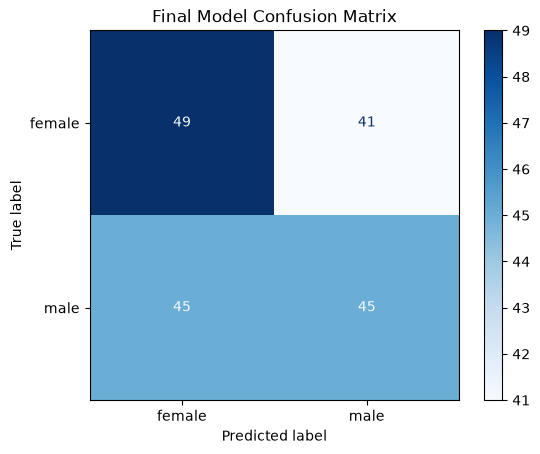

In [74]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=["female", "male"],
    cmap="Blues"
)

plt.title("Final Model Confusion Matrix")
plt.show()

## 17. Final Model vs Baseline

The final model is compared with the Dummy Classifier baseline to determine whether the machine-learning approach provides meaningful predictive improvement over a naive majority-class strategy.

In [75]:
final_comparison = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Final Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, dummy_class_pred),
        final_accuracy
    ],
    "Macro F1": [
        f1_score(
            y_test,
            dummy_class_pred,
            average="macro",
            zero_division=0
        ),
        final_f1
    ]
})

final_comparison.round(4)

,Model,Accuracy,Macro F1
0,Dummy Classifier,0.5000,0.3333
1,Final Random Forest,0.5222,0.5220


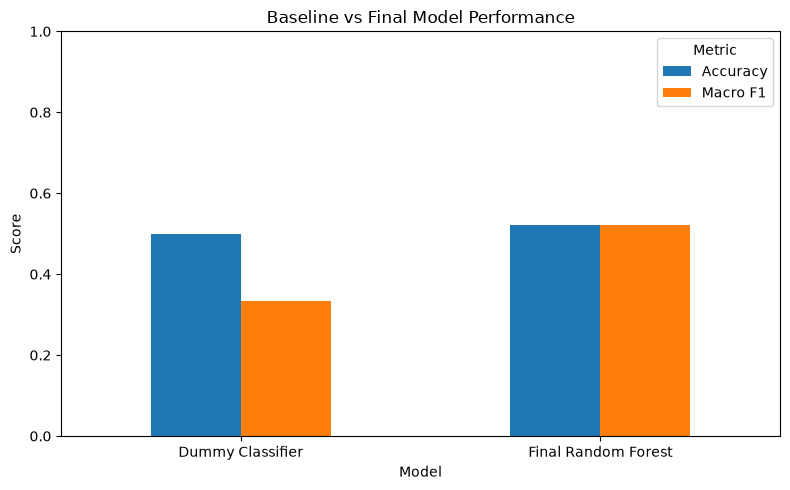

In [76]:
final_comparison_plot = final_comparison.set_index("Model")

final_comparison_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Baseline vs Final Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 18. Model Saving

The final trained pipeline is saved so that it can later be loaded for inference without separately recreating the preprocessing steps.

Saving the complete pipeline ensures that new observations receive the same One-Hot Encoding and age scaling used during model development before being passed to the classifier.

In [77]:
import joblib
import os


# Create directory if it does not already exist
os.makedirs("../models/gender_classification", exist_ok=True)


# Save complete preprocessing + model pipeline
model_path = "../models/gender_classification/gender_classifier.pkl"

joblib.dump(final_model, model_path)

print(f"Model saved successfully to: {model_path}")

Model saved successfully to: ../models/gender_classification/gender_classifier.pkl


### Saved Model Verification

The saved model is reloaded and tested to confirm that the serialized pipeline can successfully generate predictions without requiring the model to be retrained.

In [78]:
loaded_gender_model = joblib.load(model_path)

sample_predictions = loaded_gender_model.predict(X_test.head())

print("Sample Predictions:")
print(sample_predictions)

Sample Predictions:
['female' 'female' 'male' 'female' 'female']


## 19. Conclusion and Limitations

This project developed a binary classification workflow for predicting the recorded gender label of users using the available non-identifying predictors `age` and `company`.

The complete workflow included:

- data quality assessment,
- exploratory data analysis,
- target-label preparation,
- feature assessment,
- train-test splitting,
- categorical encoding and numerical scaling,
- baseline modeling,
- comparison of multiple classification algorithms,
- cross-validation,
- hyperparameter tuning,
- final model evaluation,
- and model serialization.

Exploratory analysis indicated that the available predictors contained limited separation between the gender classes. Age distributions substantially overlapped across gender categories, while the statistical analysis did not identify a significant association between company and gender.

The modeling results should therefore be interpreted in the context of the limited predictive information available in the dataset.

### Limitations

- Only `age` and `company` were retained as predictors.
- `code` was excluded because it functions as a unique identifier.
- `name` was intentionally excluded because it is a high-cardinality personal attribute and using it would largely convert the problem into name-based gender inference.
- Records with an unspecified (`none`) gender label were excluded from supervised binary classification.
- The available features may not contain sufficient information to reliably distinguish between male and female labels.
- Model performance should not be interpreted as evidence that gender can generally be inferred from age or company.
- The model is primarily useful as a demonstration of a complete classification machine-learning workflow rather than as a system for real-world gender inference.